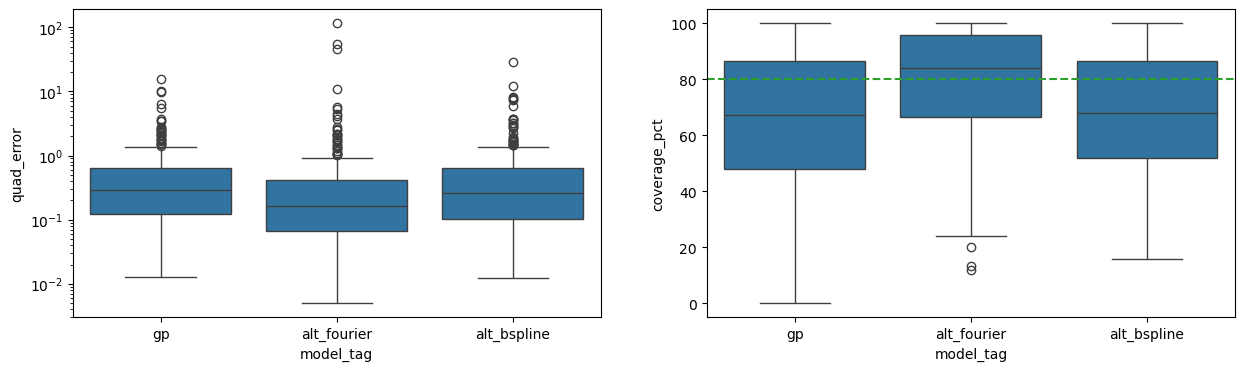

In [1]:
import pandas as pd
df = pd.read_csv('combined_coverage_all_methods.csv')

df = df[df['eval_version'] == 'lambda_projected_optimum']

import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
ax = axs[1]
sns.boxplot(data=df, x='model_tag', y='coverage_pct', ax=ax)
ax.axhline(80, color='C2', linestyle='--')
ax = axs[0]
sns.boxplot(data=df, x='model_tag', y='quad_error', ax=ax)
ax.set_yscale('log')

In [2]:
# export the figure in high resolution
fig.savefig('coverage_and_error_boxplots.png', dpi=600, bbox_inches='tight')

In [3]:
df

,seed,model_tag,mode,factor,n_coords,ci_level,lower_q,upper_q,within_count,coverage_pct,quad_error,mse,rmse,eval_version,method
0,51,gp,1,1,15,80.0,10.0,90.0,14,93.333333,0.169976,0.159943,0.399929,lambda_projected_optimum,blf_gp
1,51,gp,1,2,15,80.0,10.0,90.0,12,80.000000,0.063489,0.073608,0.271307,lambda_projected_optimum,blf_gp
2,51,gp,1,3,15,80.0,10.0,90.0,14,93.333333,0.045369,0.046735,0.216184,lambda_projected_optimum,blf_gp
3,51,gp,2,1,25,80.0,10.0,90.0,14,56.000000,1.174456,0.587195,0.766287,lambda_projected_optimum,blf_gp
4,51,gp,2,2,25,80.0,10.0,90.0,19,76.000000,0.608845,0.298662,0.546500,lambda_projected_optimum,blf_gp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1789,100,alt_bspline,1,2,15,80.0,10.0,90.0,8,53.333333,0.636012,0.714546,0.845308,lambda_projected_optimum,blf_gp
1790,100,alt_bspline,1,3,15,80.0,10.0,90.0,6,40.000000,0.884386,0.841817,0.917506,lambda_projected_optimum,blf_gp
1791,100,alt_bspline,2,1,25,80.0,10.0,90.0,23,92.000000,0.576670,0.279228,0.528421,lambda_projected_optimum,blf_gp
1792,100,alt_bspline,2,2,25,80.0,10.0,90.0,11,44.000000,8.121718,4.006421,2.001605,lambda_projected_optimum,blf_gp


In [4]:
df[df['model_tag'] == 'gp'].loc[:, 'coverage_pct'].mean()
df[df['model_tag'] == 'alt_fourier'].loc[:, 'coverage_pct'].mean()
df[df['model_tag'] == 'alt_bspline'].loc[:, 'coverage_pct'].mean()

for model in ['gp', 'alt_fourier', 'alt_bspline']:
    print(f"Model: {model}, Coverage Mean: {df[df['model_tag'] == model].loc[:, 'coverage_pct'].mean()}, Quad Error Mean: {df[df['model_tag'] == model].loc[:, 'quad_error'].mean()}")

Model: gp, Coverage Mean: 65.63555555555554, Quad Error Mean: 0.6561522196372129
Model: alt_fourier, Coverage Mean: 79.44444444444444, Quad Error Mean: 1.1456644228332633
Model: alt_bspline, Coverage Mean: 68.28, Quad Error Mean: 0.7375236318992661


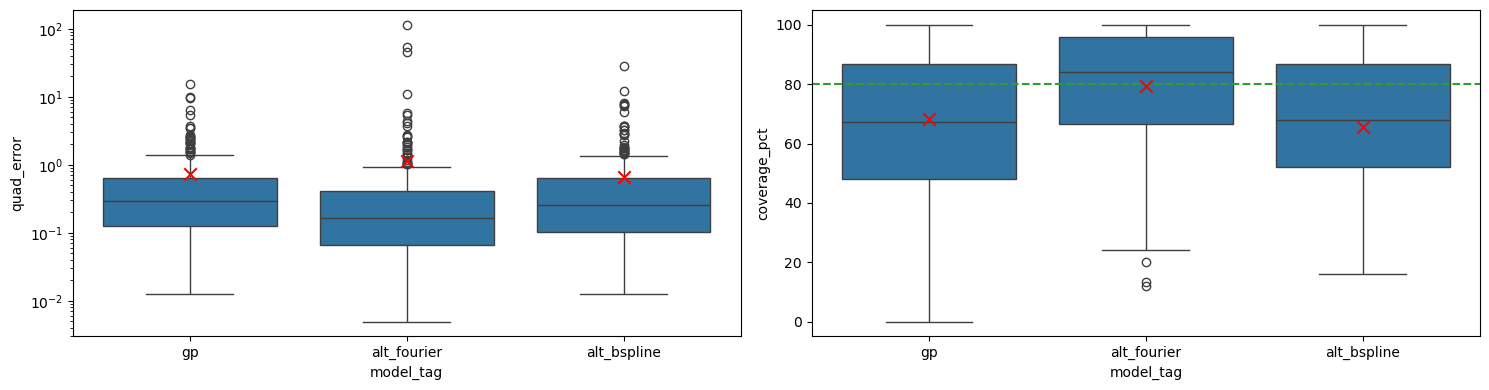

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('combined_coverage_all_methods.csv')
df = df[df['eval_version'] == 'lambda_projected_optimum']

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

# ---------- coverage_pct ----------
ax = axs[1]
sns.boxplot(data=df, x='model_tag', y='coverage_pct', ax=ax)
ax.axhline(80, color='C2', linestyle='--')

# compute means
means_cov = df.groupby('model_tag')['coverage_pct'].mean()

# x positions are 0, 1, 2, ...
x_pos = range(len(means_cov))

ax.scatter(
    x_pos,
    means_cov.values,
    color='red',
    marker='x',
    s=80,
    zorder=5
)

# ---------- quad_error ----------
ax = axs[0]
sns.boxplot(data=df, x='model_tag', y='quad_error', ax=ax)
ax.set_yscale('log')

# compute means
means_quad = df.groupby('model_tag')['quad_error'].mean()

ax.scatter(
    x_pos,
    means_quad.values,
    color='red',
    marker='x',
    s=80,
    zorder=5
)

plt.tight_layout()
plt.show()


/tmp/ipykernel_540488/1964596313.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(
/tmp/ipykernel_540488/1964596313.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(


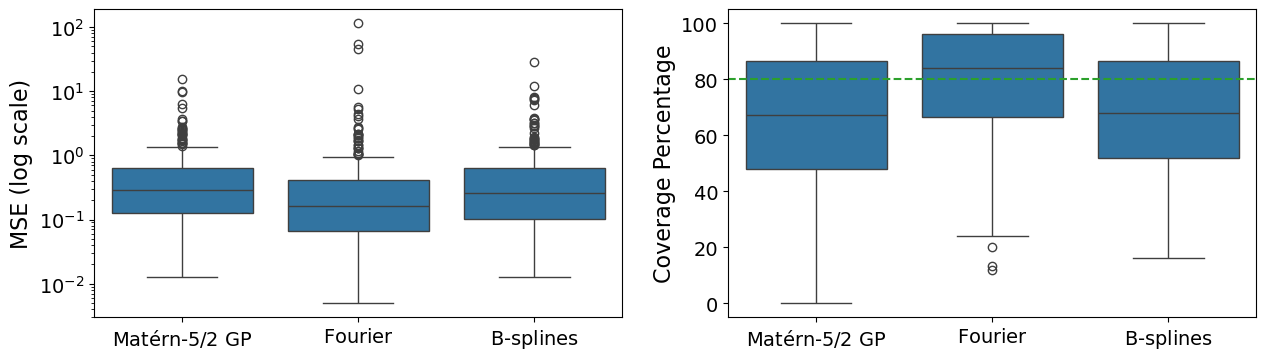

In [6]:
import pandas as pd

# sns.set_theme(
#     context="talk",   # bigger than default; good for presentations
#     style="whitegrid",
#     font_scale=1.4    # increase text size further
# )

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

df = pd.read_csv('combined_coverage_all_methods.csv')

df = df[df['eval_version'] == 'lambda_projected_optimum']

import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
ax = axs[1]
sns.boxplot(data=df, x='model_tag', y='coverage_pct', ax=ax)
ax.axhline(80, color='C2', linestyle='--')
ax = axs[0]
sns.boxplot(data=df, x='model_tag', y='quad_error', ax=ax)
ax.set_yscale('log')

axs[0].set_xticklabels(
    [
        r'$\text{Matérn-}5/2\text{ GP}$',
        r'$\text{Fourier}$',
        r'$\text{B-splines}$',
    ]
)

axs[1].set_xticklabels(
    [
        r'$\text{Matérn-}5/2\text{ GP}$',
        r'$\text{Fourier}$',
        r'$\text{B-splines}$',
    ]
)

axs[0].set_ylabel('MSE (log scale)')
axs[1].set_ylabel('Coverage Percentage')
axs[0].set_xlabel('')
axs[1].set_xlabel('')

fig.savefig('truth_is_fourier.png', dpi=600, bbox_inches='tight')


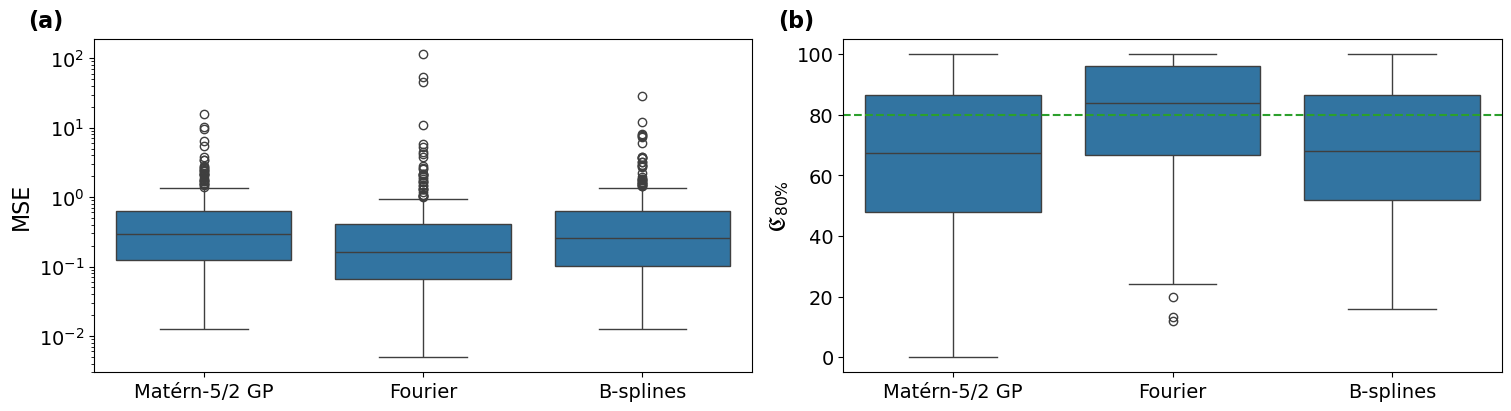

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Optional
# sns.set_theme(context="talk", style="whitegrid", font_scale=1.4)

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

df = pd.read_csv("combined_coverage_all_methods.csv")
df = df[df["eval_version"] == "lambda_projected_optimum"].copy()

if df.empty:
    raise ValueError("No rows remain after filtering eval_version == 'lambda_projected_optimum'.")

# Use the order that actually appears in the data
order = list(pd.unique(df["model_tag"]))

# Pretty labels only for values that are present
label_map = {
    "gp": r"Matérn-5/2 GP",
    "alt_fourier": r"Fourier",
    "alt_bspline": r"B-splines",
}

xticklabels = [label_map.get(x, x) for x in order]

fig, axs = plt.subplots(1, 2, figsize=(15, 4), constrained_layout=True)

# (a) MSE
sns.boxplot(data=df, x="model_tag", y="quad_error", order=order, ax=axs[0])
axs[0].set_yscale("log")
axs[0].set_ylabel("MSE")
axs[0].set_xlabel("")
axs[0].set_xticks(range(len(order)))
axs[0].set_xticklabels(xticklabels)
axs[0].text(
    -0.10, 1.02, "(a)",
    transform=axs[0].transAxes,
    fontsize=16,
    fontweight="bold",
    va="bottom",
    ha="left",
)

# (b) Coverage
sns.boxplot(data=df, x="model_tag", y="coverage_pct", order=order, ax=axs[1])
axs[1].axhline(80, color="C2", linestyle="--")
# axs[1].set_ylabel(r"$\text{Coverage}_{80\%}$")
axs[1].set_ylabel(r"$\mathfrak{C}_{80\%}$")
axs[1].set_xlabel("")
axs[1].set_xticks(range(len(order)))
axs[1].set_xticklabels(xticklabels)
axs[1].text(
    -0.10, 1.02, "(b)",
    transform=axs[1].transAxes,
    fontsize=16,
    fontweight="bold",
    va="bottom",
    ha="left",
)

fig.savefig("truth_is_fourier.png", dpi=600, bbox_inches="tight")
plt.show()